# Setup and importing librarires

In [1]:
!pip install -q tensorflow matplotlib scikit-learn pillow

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.20.0
All libraries imported successfully!


# Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Set the root path of ml_pest folder
ROOT_PATH = "/content/drive/MyDrive/ml_pest"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Understanding & Visualisation

### Explore the Dataset Structure

In [27]:
import os
import yaml
import shutil
from tqdm import tqdm

# Define the path for the data.yaml file
yaml_file_path = os.path.join(ROOT_PATH, 'data.yaml')

# Load class names from data.yaml
with open(yaml_file_path, 'r') as f:
    data = yaml.safe_load(f)
    class_names_from_yaml = data['names'] # Use a temporary name to avoid conflict initially
    num_classes_from_yaml = len(class_names_from_yaml)

print(f"Loaded {num_classes_from_yaml} class names from data.yaml: {class_names_from_yaml}")

# Define a new directory to store the restructured dataset
RESTRUCTURED_ROOT = "/content/restructured_dataset"

# Remove existing restructured_dataset if it exists to ensure a clean start
if os.path.exists(RESTRUCTURED_ROOT):
    print(f"Removing existing restructured dataset at {RESTRUCTURED_ROOT}...")
    shutil.rmtree(RESTRUCTURED_ROOT)

os.makedirs(RESTRUCTURED_ROOT, exist_ok=True)

# Process each split (train, valid, test)
splits = ['train', 'valid', 'test']

for split in splits:
    original_image_dir = os.path.join(ROOT_PATH, split, 'images')
    original_label_dir = os.path.join(ROOT_PATH, split, 'labels')
    restructured_split_dir = os.path.join(RESTRUCTURED_ROOT, split)

    print(f"\nRestructuring {split} split...")
    os.makedirs(restructured_split_dir, exist_ok=True)

    # Create class subdirectories within the restructured split directory
    for class_name in class_names_from_yaml: # Use class_names_from_yaml here
        os.makedirs(os.path.join(restructured_split_dir, class_name), exist_ok=True)

    image_files = os.listdir(original_image_dir)
    print(f"Found {len(image_files)} images in {original_image_dir}")

    # Use tqdm for a progress bar
    for img_file in tqdm(image_files, desc=f"Processing {split} images"):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        # Construct paths
        src_img_path = os.path.join(original_image_dir, img_file)
        # Assuming label file has same base name but .txt extension
        label_file_name = img_file.rsplit('.', 1)[0] + '.txt'
        src_label_path = os.path.join(original_label_dir, label_file_name)

        if os.path.exists(src_label_path):
            with open(src_label_path, 'r') as f_label:
                first_line = f_label.readline().strip()
                if first_line:
                    class_id = int(first_line.split()[0])
                    if 0 <= class_id < num_classes_from_yaml: # Use num_classes_from_yaml
                        class_name = class_names_from_yaml[class_id] # Use class_names_from_yaml
                        dest_class_dir = os.path.join(restructured_split_dir, class_name)
                        dest_img_path = os.path.join(dest_class_dir, img_file)
                        shutil.copy(src_img_path, dest_img_path)
                    else:
                        print(f"Warning: Class ID {class_id} out of range for image {img_file}. Skipping.")
                else:
                    print(f"Warning: Label file {label_file_name} is empty for image {img_file}. Skipping.")
        else:
            print(f"Warning: Label file {label_file_name} not found for image {img_file}. Skipping.")

print(f"\nDataset successfully restructured into: {RESTRUCTURED_ROOT}")

# Now, update the global variables `train_dir`, `valid_dir`, `test_dir`
# and `class_names`, `num_classes` to reflect the restructured dataset.
train_dir = os.path.join(RESTRUCTURED_ROOT, "train")
valid_dir = os.path.join(RESTRUCTURED_ROOT, "valid")
test_dir  = os.path.join(RESTRUCTURED_ROOT, "test")

# Get class names by listing subdirectories of the restructured train_dir
class_names = sorted([d for d in os.listdir(train_dir)
                      if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(class_names)

print(f"\nUpdated directory information:")
print(f"Found {num_classes} classes: {class_names}")
print(f"Train directory: {train_dir}")
print(f"Valid directory: {valid_dir}")
print(f"Test directory : {test_dir}")

Loaded 100 class names from data.yaml: ['Zingiber officinale -ginger-', 'almonds', 'aloe vera', 'apple fruit', 'apricot', 'areca nut', 'ashwagandha', 'avacado', 'bamboo', 'banana', 'beetroot', 'bell pepper -capsicum-', 'bitter gourd', 'black pepper', 'blackberry fruit', 'blackgram', 'blueberry fruit', 'bottle gourd', 'brinjal', 'brocoli', 'cabbage', 'cactus', 'cardamom', 'carrot', 'cashew', 'cassava', 'cauliflower', 'chamomile', 'cherry', 'chilli pepper', 'cinnamon', 'coconut', 'coffee beans', 'coriander', 'cotton', 'cucumber', 'date palm', 'dates', 'dragon fruit', 'figs -anjeer-', 'garlic', 'grapes', 'green gram -mung bean-', 'groundnut-peanut-', 'guava', 'jaggery', 'jute', 'kidney bean', 'kiwi fruit', 'lavender plant', 'lemon', 'lychee', 'maize', 'mango', 'mint herb', 'mushroom', 'muskmelon', 'mustard crop', 'oats', 'okra -ladyfinger-', 'onion', 'orange', 'orchid orchidaceae', 'papaya', 'pea', 'peach', 'pear fruit', 'pineapple', 'pista -pistachio-', 'plum fruit', 'pomegranate', 'pome

Processing train images:   3%|▎         | 440/17553 [02:29<04:32, 62.86it/s]

Processing train images:   5%|▌         | 936/17553 [02:32<01:46, 156.64it/s]

Processing train images:   7%|▋         | 1288/17553 [02:34<01:43, 157.22it/s]

Processing train images:   8%|▊         | 1338/17553 [02:35<01:40, 162.04it/s]

...

Processing test images:  76%|███████▌  | 1867/2458 [14:31<05:05,  1.93it/s]

Processing test images:  85%|████████▌ | 2095/2458 [16:13<02:48,  2.15it/s]

Processing test images:  86%|████████▌ | 2110/2458 [16:19<02:47,  2.08it/s]

Processing test images: 100%|██████████| 2458/2458 [18:56<00:00,  2.16it/s]


Dataset successfully restructured into: /content/restructured_dataset

Updated directory information:
Found 100 classes: ['Zingiber officinale -ginger-', 'almonds', 'aloe vera', 'apple fruit', 'apricot', 'areca nut', 'ashwagandha', 'avacado', 'bamboo', 'banana', 'beetroot', 'bell pepper -capsicum-', 'bitter gourd', 'black pepper', 'blackberry fruit', 'blackgram', 'blueberry fruit', 'bottle gourd', 'brinjal', 'brocoli', 'cabbage', 'cactus', 'cardamom', 'carrot', 'cashew', 'cassava', 'cauliflower', 'chamomile', 'cherry', 'chilli pepper', 'cinnamon', 'coconut', 'coffee beans', 'coriander', 'cotton', 'cucumber', 'date palm', 'dates', 'dragon fruit', 'figs -anjeer-', 'garlic', 'grapes', 'green gram -mung bean-', 'groundnut-peanut-', 'guava', 'jaggery', 'jute', 'kidney bean', 'kiwi fruit', 'lavender plant', 'lemon', 'lychee', 'maize', 'mango', 'mint herb', 'mushroom', 'muskmelon', 'mustard crop', 'oats', 'okra -ladyfinger-', 'onion', 'orange', 'orchid orchidaceae', 'papaya', 'pea', 'peach',

# sample images of the dataset

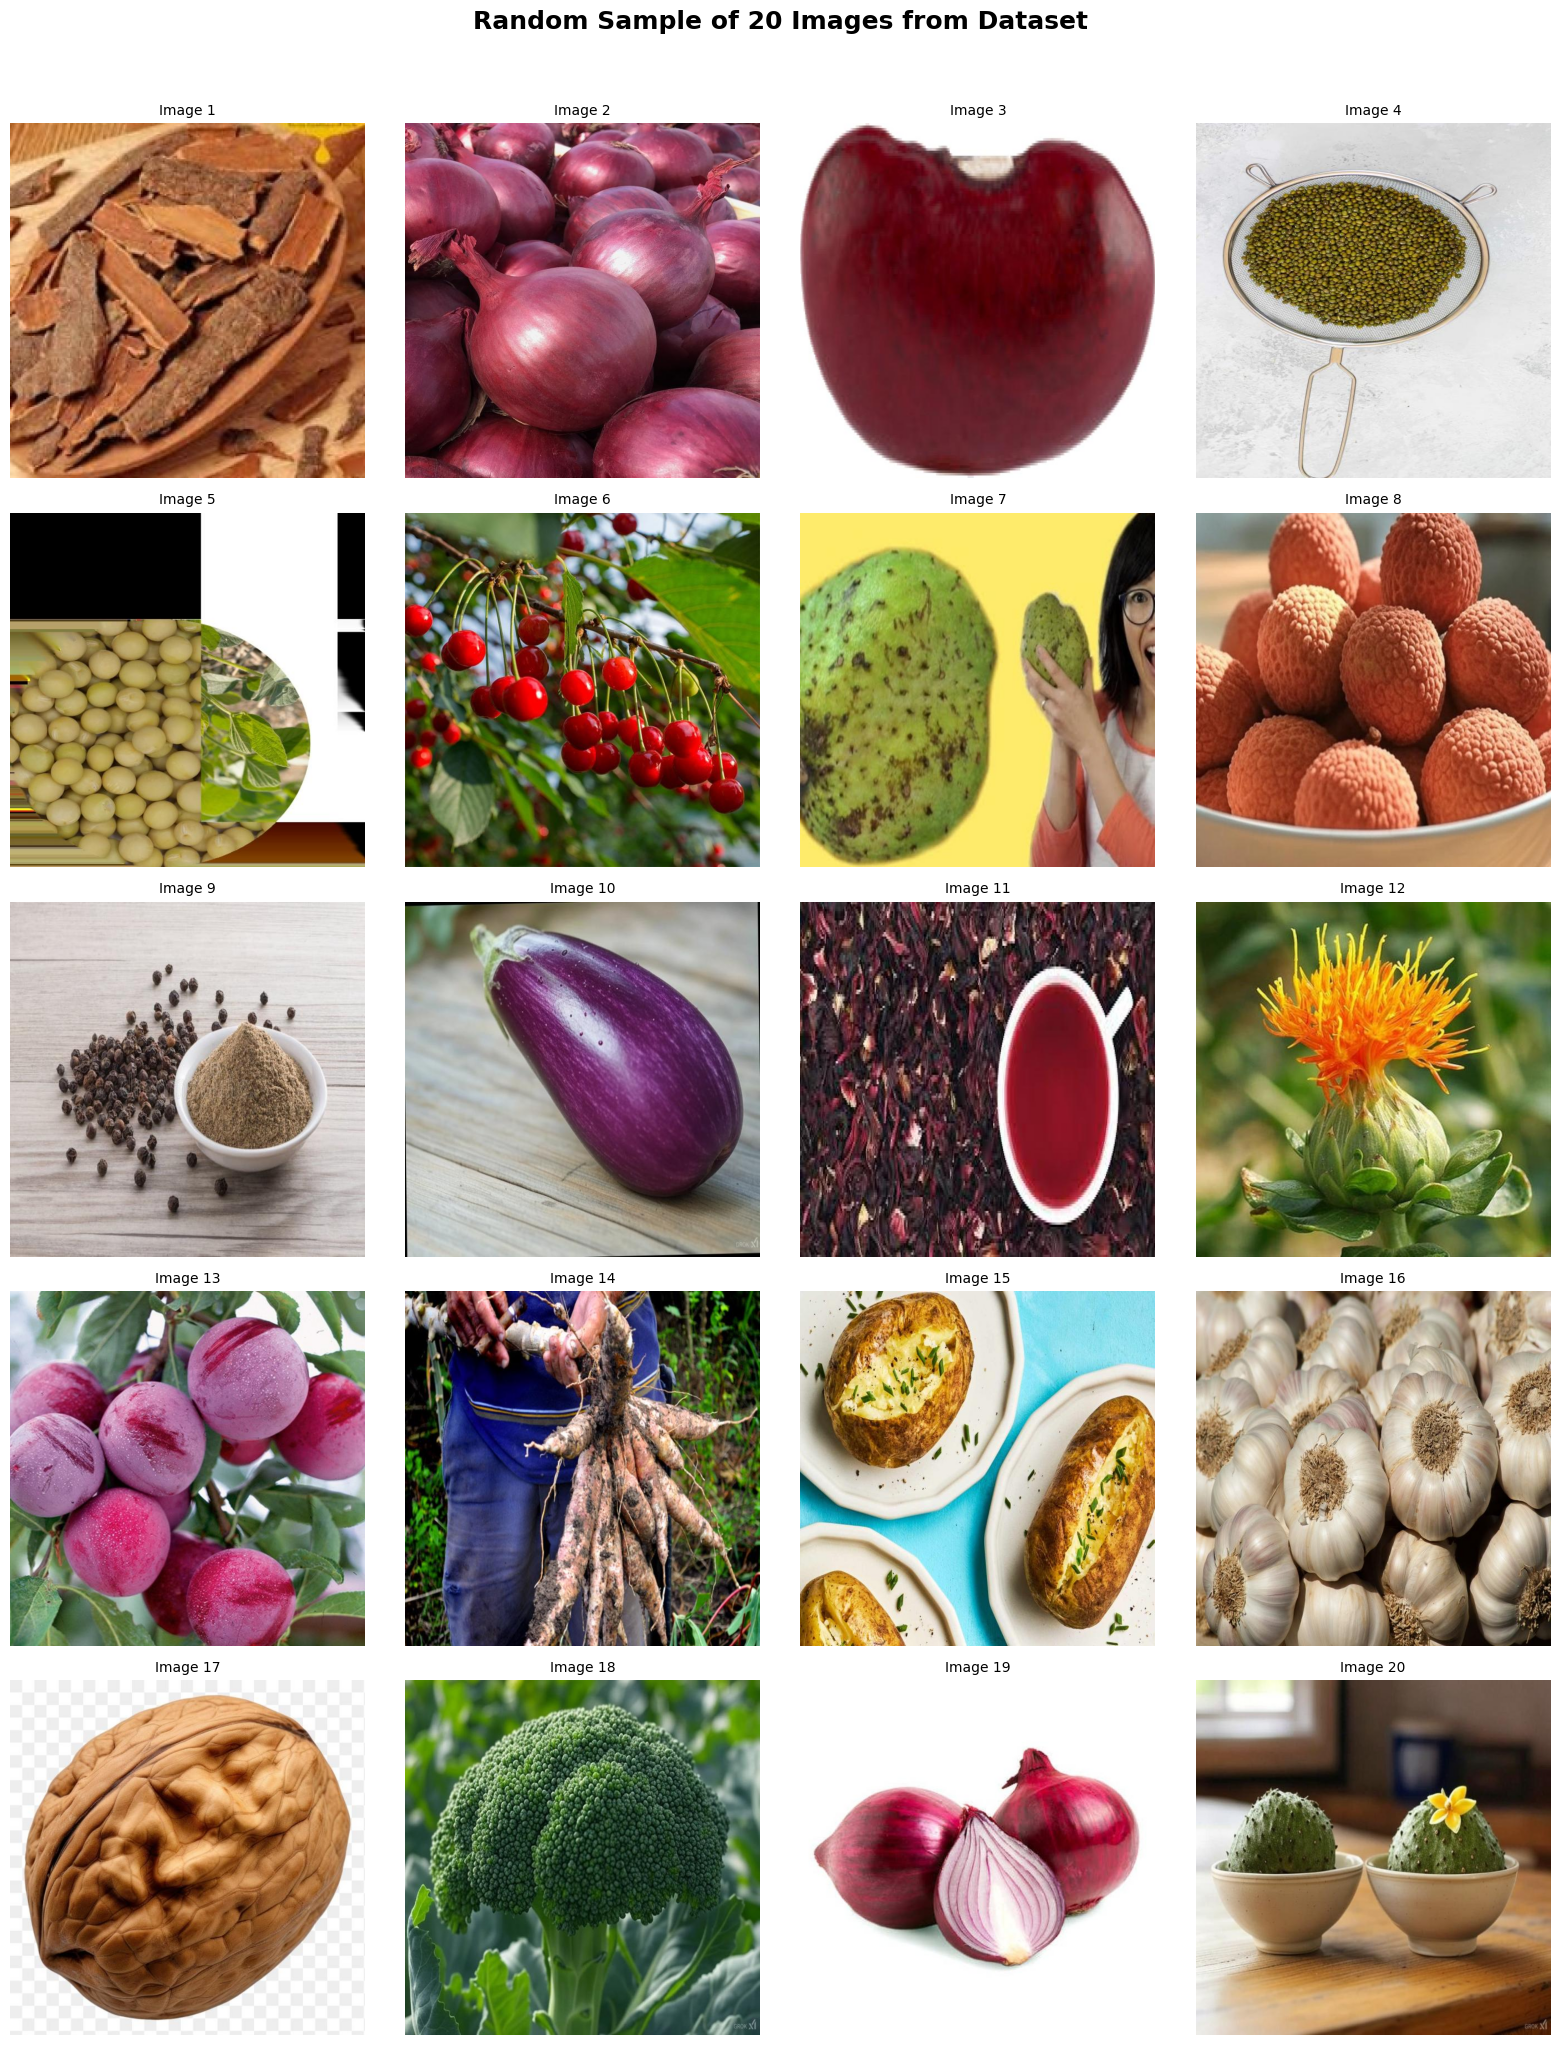

Displayed 20 random images.


In [4]:
target_dir = os.path.join(train_dir, 'images') # Updated to point to the 'images' subdirectory

# 1. Gather all valid image files in the directory
all_images = [f for f in os.listdir(target_dir)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

num_to_sample = 20
if len(all_images) < num_to_sample:
    print(f"Only found {len(all_images)} images. Showing all of them.")
    num_to_sample = len(all_images)

# Handle the case where no images are found even after correction
if num_to_sample == 0:
    print(f"No images found in {target_dir}. Cannot display samples.")
else:
    # 2. Randomly select the images
    sample_list = random.sample(all_images, num_to_sample)

    # 3. Setup the Grid (4 columns looks good for 20 images)
    cols = 4
    rows = (num_to_sample + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    # 4. Plotting
    for i in range(num_to_sample):
        img_path = os.path.join(target_dir, sample_list[i])
        img = Image.open(img_path)

        axes[i].imshow(img)
        axes[i].set_title(f"Image {i+1}", fontsize=10)
        axes[i].axis('off')

    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Random Sample of {num_to_sample} Images from Dataset', fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('dataset_samples.png', bbox_inches='tight')
    plt.show()

    print(f"Displayed {num_to_sample} random images.")

In [5]:
# @title  Check for Corrupted Images
corrupted = []
for cls in class_names:
    cls_path = os.path.join(train_dir, cls)
    for fname in os.listdir(cls_path):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')):
            continue
        fpath = os.path.join(cls_path, fname)
        try:
            with Image.open(fpath) as img:
                img.verify()
        except (IOError, SyntaxError):
            corrupted.append(fpath)
            os.remove(fpath)
            print(f"Removed corrupted: {fpath}")

if not corrupted:
    print("No corrupted images found.")
else:
    print(f"Removed {len(corrupted)} corrupted images.")

No corrupted images found.


train: 17553 images
valid: 4990 images
test: 2458 images
Total classes: 100
Average width: 640 pixels
Average height: 640 pixels


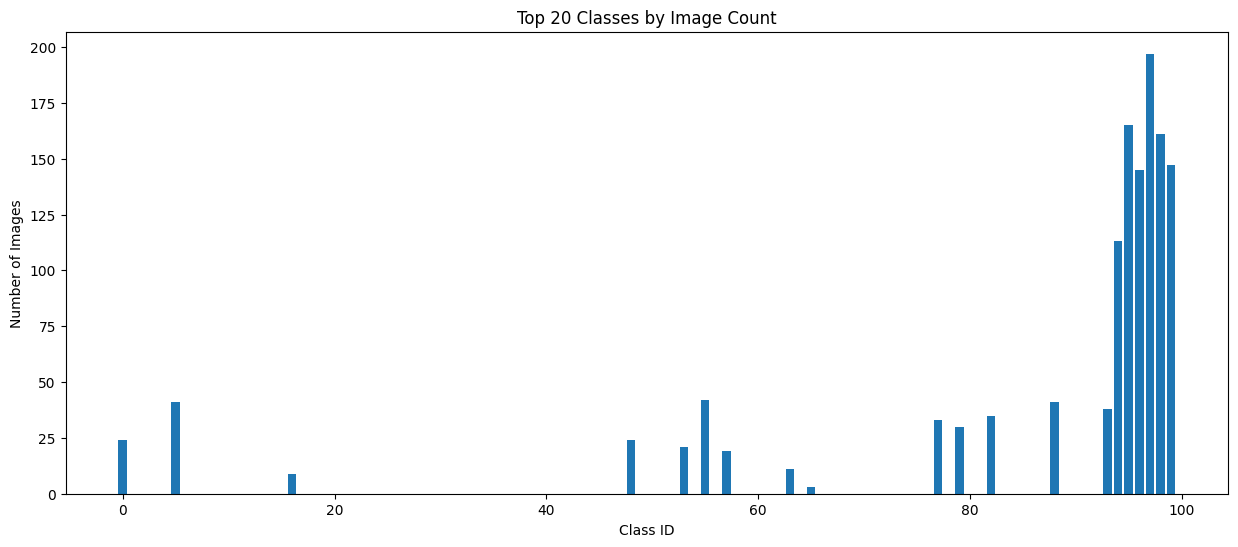

In [7]:
import os
import cv2
import yaml
import matplotlib.pyplot as plt
from collections import defaultdict

# Set the root path of ml_pest folder
ROOT_PATH = "/content/drive/MyDrive/ml_pest"

# Path to the data.yaml file
yaml_file_path = os.path.join(ROOT_PATH, 'data.yaml')

# 1. Count images in each split
splits = ['train', 'valid', 'test']
for split in splits:
    img_path = os.path.join(ROOT_PATH, split, 'images')
    count = len(os.listdir(img_path))
    print(f"{split}: {count} images")

# 2. Load class names
with open(yaml_file_path, 'r') as f:
    data = yaml.safe_load(f)
    class_names = data['names']
    print(f"Total classes: {len(class_names)}")

# 3. Count images per class from labels
class_counts = defaultdict(int)

train_labels_path = os.path.join(ROOT_PATH, 'train', 'labels')
for label_file in os.listdir(train_labels_path)[:1000]:
    with open(os.path.join(train_labels_path, label_file), 'r') as f:
        for line in f:
            class_id = int(line.strip().split()[0])
            class_counts[class_id] += 1

# 4. Check image dimensions
sample_images = os.listdir(os.path.join(ROOT_PATH, 'train', 'images'))[:100]
widths, heights = [], []
for img_name in sample_images:
    img = cv2.imread(os.path.join(ROOT_PATH, 'train', 'images', img_name))
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print(f"Average width: {sum(widths)/len(widths):.0f} pixels")
print(f"Average height: {sum(heights)/len(heights):.0f} pixels")

# 5. Plot class distribution
plt.figure(figsize=(15, 6))
# Filter classes to only include those that actually have counts and take top 20
sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
classes_to_plot = [class_id for class_id, count in sorted_classes[:20]]
counts_to_plot = [count for class_id, count in sorted_classes[:20]]

plt.bar(classes_to_plot, counts_to_plot)
plt.title('Top 20 Classes by Image Count')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.show()

# PIE CHART OF DATASET SPLITS

PART 3: PIE CHART OF DATASET SPLITS


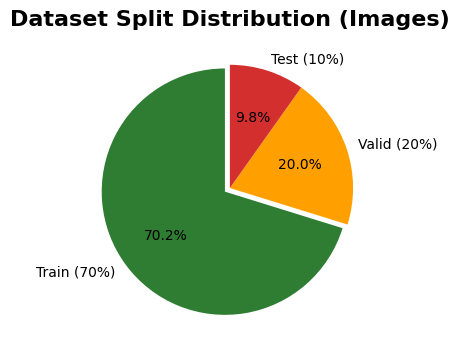


Saved: 02_pie_chart.png


In [13]:
import matplotlib.pyplot as plt
import os

print("=" * 50)
print("PART 3: PIE CHART OF DATASET SPLITS")
print("=" * 50)

# Recalculate image counts (since previous cell didn't store them in global variables)
train_images = len(os.listdir(os.path.join(ROOT_PATH, 'train', 'images')))
valid_images = len(os.listdir(os.path.join(ROOT_PATH, 'valid', 'images')))
test_images = len(os.listdir(os.path.join(ROOT_PATH, 'test', 'images')))

# Define splits_info using the newly calculated image counts
splits_info = {
    'train': {'images': train_images},
    'valid': {'images': valid_images},
    'test': {'images': test_images}
}

sizes = [splits_info['train']['images'], splits_info['valid']['images'], splits_info['test']['images']]
labels = ['Train (70%)', 'Valid (20%)', 'Test (10%)']
colors = ['#2E7D32', '#FFA000', '#D32F2F']

plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=(0.05, 0, 0))
plt.title('Dataset Split Distribution (Images)', fontsize=16, fontweight='bold')
plt.savefig('02_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: 02_pie_chart.png")

# Class Distribution Chart

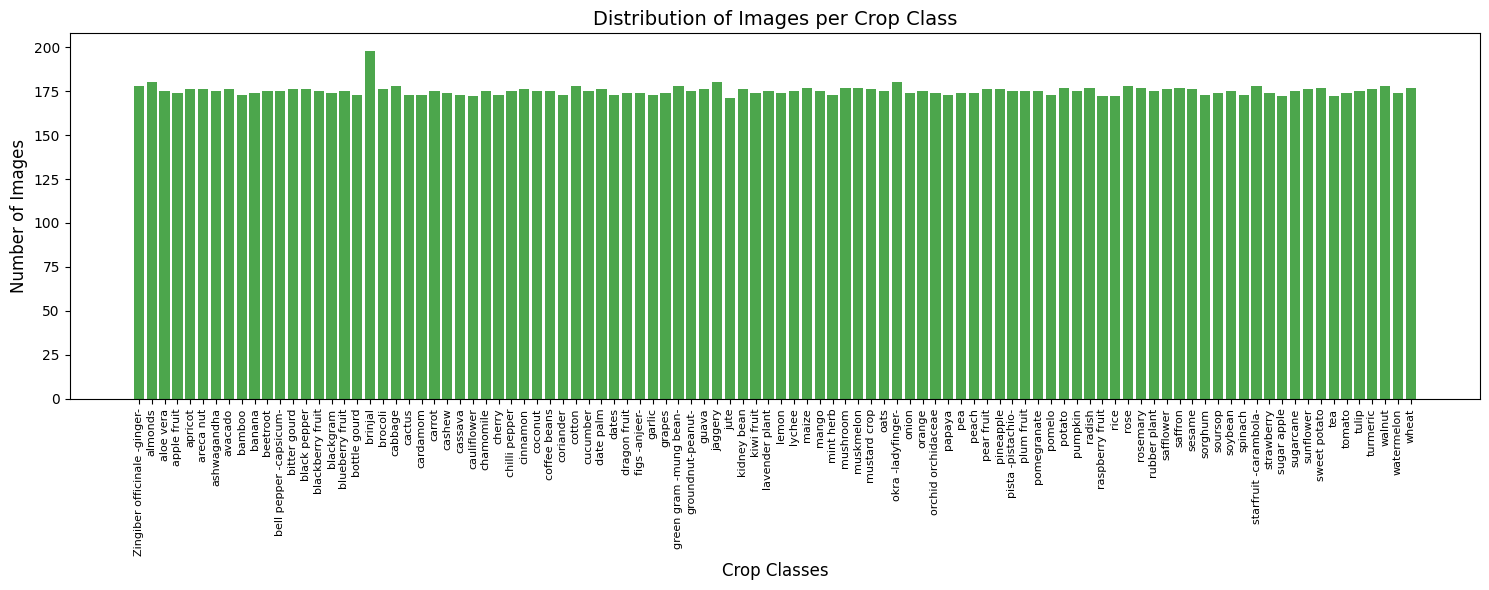

Total classes with detected instances: 100
Average images per class: 175
Saved: class_distribution.png


In [16]:
import yaml
from collections import defaultdict
import os
import matplotlib.pyplot as plt

# Load class names from data.yaml
yaml_path = os.path.join(ROOT_PATH, 'data.yaml') # Use ROOT_PATH
with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)
    class_names = data['names']

# Define train_labels_path and images for this cell
train_labels_path = os.path.join(ROOT_PATH, 'train', 'labels')
train_images_path = os.path.join(ROOT_PATH, 'train', 'images')
images = os.listdir(train_images_path) # List all image files in the training folder

# Count images per class from labels
class_counts = defaultdict(int)

for img_name in images:
    label_name = img_name.replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt') # Handle .jpeg too
    label_path = os.path.join(train_labels_path, label_name)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            # Read only the first line to get the primary class if there are multiple objects
            first_line = f.readline().strip()
            if first_line:
                class_id = int(first_line.split()[0])
                class_counts[class_id] += 1

# Create bar chart
plt.figure(figsize=(15, 6))
# Get sorted class IDs and counts, then map to class names
sorted_class_counts = sorted(class_counts.items(), key=lambda item: item[0])
classes = [cls_id for cls_id, _ in sorted_class_counts]
counts = [count for _, count in sorted_class_counts]

# Use class_names for labels
class_labels = [class_names[c] for c in classes if c < len(class_names)]

plt.bar(class_labels, counts, color='green', alpha=0.7)
plt.xlabel('Crop Classes', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Images per Crop Class', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

# Create the directory if it doesn't exist
os.makedirs('/content/illustrations', exist_ok=True)
plt.savefig('/content/illustrations/class_distribution.png', dpi=150, bbox_inches='tight')
plt.close()

print(f"Total classes with detected instances: {len(class_counts)}")
if len(class_counts) > 0:
    print(f"Average images per class: {sum(counts)/len(counts):.0f}")
else:
    print("No class instances found.")
print("Saved: class_distribution.png")

# Sample Augmentations

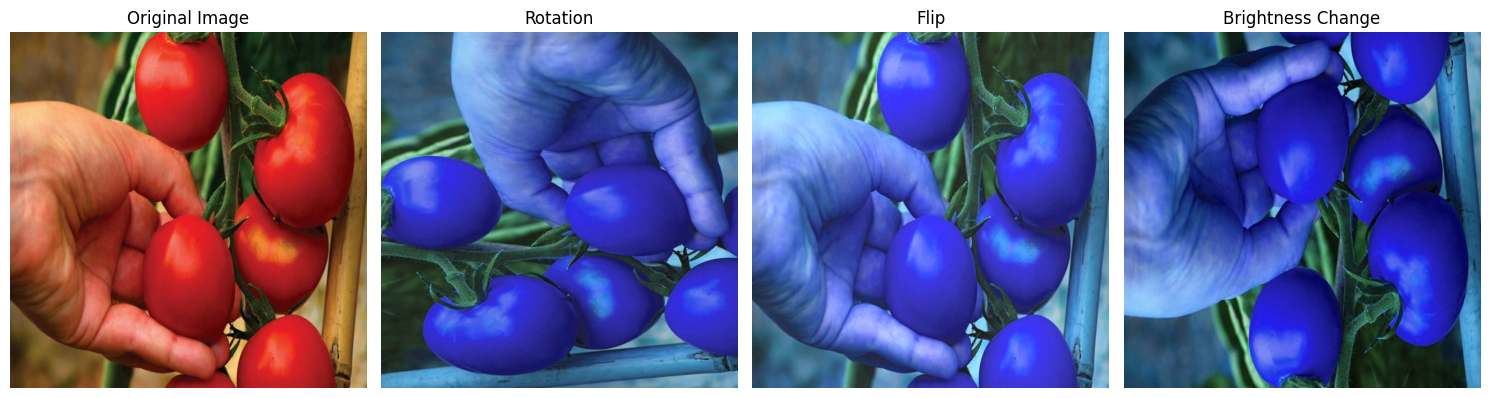

In [17]:
import albumentations as A

# Define augmentations
transform = A.Compose([
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
])

# Pick one image
sample_img_path = os.path.join(train_images_path, images[5])
img = cv2.imread(sample_img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Apply augmentations
augmented1 = transform(image=img)['image']
augmented2 = transform(image=img)['image']
augmented3 = transform(image=img)['image']

# Plot original and augmented
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Original Image')

plt.subplot(1, 4, 2)
plt.imshow(augmented1)
plt.axis('off')
plt.title('Rotation')

plt.subplot(1, 4, 3)
plt.imshow(augmented2)
plt.axis('off')
plt.title('Flip')

plt.subplot(1, 4, 4)
plt.imshow(augmented3)
plt.axis('off')
plt.title('Brightness Change')

plt.tight_layout()
plt.show()

### Create TensorFlow Datasets

In [38]:
IMG_HEIGHT, IMG_WIDTH = 124, 124
BATCH_SIZE = 16
SEED = 42

# Helper: rescale pixels to [0,1]
def prepare_ds(ds):
    return ds.map(lambda x, y: (x/255.0, y))

# Training set
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# Get class names before mapping
class_names = train_ds_raw.class_names
num_classes = len(class_names)

train_ds = prepare_ds(train_ds_raw)

# Validation set (explicit folder)
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)
val_ds = prepare_ds(val_ds_raw)

# Test set (explicit folder)
test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)
test_ds = prepare_ds(test_ds_raw)

print(f"\nClasses: {class_names}")
print(f"Train batches: {len(train_ds)} | Valid batches: {len(val_ds)} | Test batches: {len(test_ds)}")

Found 17530 files belonging to 100 classes.
Found 4981 files belonging to 100 classes.
Found 2454 files belonging to 100 classes.

Classes: ['Zingiber officinale -ginger-', 'almonds', 'aloe vera', 'apple fruit', 'apricot', 'areca nut', 'ashwagandha', 'avacado', 'bamboo', 'banana', 'beetroot', 'bell pepper -capsicum-', 'bitter gourd', 'black pepper', 'blackberry fruit', 'blackgram', 'blueberry fruit', 'bottle gourd', 'brinjal', 'brocoli', 'cabbage', 'cactus', 'cardamom', 'carrot', 'cashew', 'cassava', 'cauliflower', 'chamomile', 'cherry', 'chilli pepper', 'cinnamon', 'coconut', 'coffee beans', 'coriander', 'cotton', 'cucumber', 'date palm', 'dates', 'dragon fruit', 'figs -anjeer-', 'garlic', 'grapes', 'green gram -mung bean-', 'groundnut-peanut-', 'guava', 'jaggery', 'jute', 'kidney bean', 'kiwi fruit', 'lavender plant', 'lemon', 'lychee', 'maize', 'mango', 'mint herb', 'mushroom', 'muskmelon', 'mustard crop', 'oats', 'okra -ladyfinger-', 'onion', 'orange', 'orchid orchidaceae', 'papaya

### Build Baseline CNN

In [44]:
def build_baseline(input_shape, num_classes):
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
baseline_model = build_baseline(input_shape, num_classes)
baseline_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 124, 124, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 62, 62, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │     1,968,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,999,556 (7.63 MB)

 Trainable params: 1,999,556 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

## Train Baseline Model


In [45]:
# --- CALLBACKS ---
checkpoint = ModelCheckpoint("baseline_best.h5",
                             save_best_only=True,
                             monitor='val_loss', # Switching to loss is often safer
                             mode='min')

earlystop = EarlyStopping(patience=5, # Reduced patience to stop sooner if it goes south
                          restore_best_weights=True)

# --- TRAINING ---
history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint, earlystop],
    verbose=1
)

Epoch 1/30
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.0274 - loss: 4.3823

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 49s 41ms/step - accuracy: 0.0483 - loss: 4.1322 - val_accuracy: 0.0956 - val_loss: 3.7621
Epoch 2/30
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1227 - loss: 3.5399

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.1439 - loss: 3.4020 - val_accuracy: 0.1498 - val_loss: 3.4609
Epoch 3/30
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1892 - loss: 3.1361

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 43s 39ms/step - accuracy: 0.2068 - loss: 3.0247 - val_accuracy: 0.1945 - val_loss: 3.2347
Epoch 4/30
1094/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2554 - loss: 2.7901

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 81s 39ms/step - accuracy: 0.2790 - loss: 2.6890 - val_accuracy: 0.2116 - val_loss: 3.1803
Epoch 5/30
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.3517 - loss: 2.3567 - val_accuracy: 0.2180 - val_loss: 3.3091
Epoch 6/30
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.4295 - loss: 2.0394 - val_accuracy: 0.2247 - val_loss: 3.6005
Epoch 7/30
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.5009 - loss: 1.7509 - val_accuracy: 0.2273 - val_loss: 3.9434
Epoch 8/30
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 83s 39ms/step - accuracy: 0.5769 - loss: 1.4826 - val_accuracy: 0.2295 - val_loss: 4.5016
Epoch 9/30
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.6453 - loss: 1.2309 - val_accuracy: 0.2146 - val_loss: 5.1186


### Evaluate Baseline on Test Set


In [46]:
current_img_height = 124
current_img_width = 124
current_batch_size = 32
current_seed = 42

# Helper function to normalize images, needed for the newly created test_ds
def prepare_ds_for_eval(ds):
    return ds.map(lambda x, y: (x / 255.0, y))

# Test set with consistent parameters
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(current_img_height, current_img_width),
    batch_size=current_batch_size,
    shuffle=False,
    seed=current_seed
)
test_ds = prepare_ds_for_eval(test_ds_raw)

test_loss, test_acc = baseline_model.evaluate(test_ds)
print(f"\n Baseline CNN - Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%%)")
print(f"   Test Loss: {test_loss:.4f}")

# Classification Report
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = baseline_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report (Baseline CNN):")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 2454 files belonging to 100 classes.
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.2196 - loss: 3.1366

 Baseline CNN - Test Accuracy: 0.2196 (21.96%%)
   Test Loss: 3.1366

Classification Report (Baseline CNN):
                              precision    recall  f1-score   support

Zingiber officinale -ginger-       0.18      0.12      0.14        26
                     almonds       0.17      0.35      0.23        23
                   aloe vera       0.08      0.08      0.08        25
                 apple fruit       0.08      0.04      0.05        24
                     apricot       0.23      0.58      0.33        24
                   areca nut       0.33      0.08      0.13        24
                 ashwagandha       0.10      0.08      0.09        25
                     avacado       0.19      0.20      0.20        25
                      bamboo       0.25      0.09      0.13        23
                      banana       0.17      0.32      0.22        25
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Plot Training Curves (Baseline)

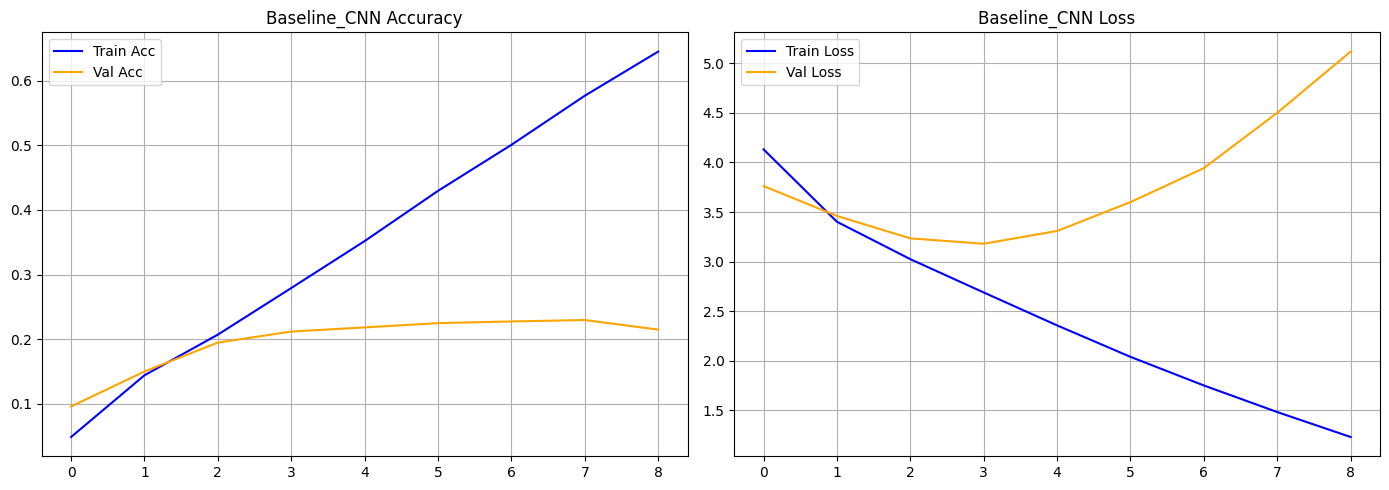

In [47]:
def plot_history(hist, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    axes[0].plot(hist.history['accuracy'], label='Train Acc', color='b')
    axes[0].plot(hist.history['val_accuracy'], label='Val Acc', color='orange')
    axes[0].set_title(f'{title_prefix} Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(hist.history['loss'], label='Train Loss', color='b')
    axes[1].plot(hist.history['val_loss'], label='Val Loss', color='orange')
    axes[1].set_title(f'{title_prefix} Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f'{title_prefix}_curves.png')
    plt.show()

plot_history(history, "Baseline_CNN")

## Build Improved CNN with Data Augmentation

In [48]:
# @title 11. Build Improved CNN with Data Augmentation
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

def build_improved_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = data_aug(inputs)
    x = layers.Rescaling(1./255)(x)    # explicit rescaling

    # Block 1
    x = layers.Conv2D(32, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Dense head
    x = layers.Flatten()(x)
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

improved_model = build_improved_cnn(input_shape, num_classes)
improved_model.compile(optimizer=Adam(learning_rate=1e-3),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])
improved_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_7 (Sequential)       │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 124, 124, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 124, 124, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 124, 124, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 62, 62, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 62, 62, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 62, 62, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 31, 31, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 31, 31, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 31, 31, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 31, 31, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,157,316 (27.30 MB)

 Trainable params: 7,154,436 (27.29 MB)

 Non-trainable params: 2,880 (11.25 KB)

## Train Improved CNN

In [49]:
checkpoint_imp = ModelCheckpoint("improved_best.h5", save_best_only=True, monitor='val_accuracy')
earlystop_imp = EarlyStopping(patience=10, restore_best_weights=True)

history = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_imp, earlystop_imp],
    verbose=1
)

Epoch 1/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.0236 - loss: 4.8120

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 76s 63ms/step - accuracy: 0.0366 - loss: 4.4561 - val_accuracy: 0.0787 - val_loss: 3.8601
Epoch 2/20
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.0710 - loss: 3.8838

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 74s 68ms/step - accuracy: 0.0827 - loss: 3.7986 - val_accuracy: 0.1257 - val_loss: 3.5322
Epoch 3/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1081 - loss: 3.6163

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.1134 - loss: 3.5799 - val_accuracy: 0.1301 - val_loss: 3.5414
Epoch 4/20
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1357 - loss: 3.4568

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.1405 - loss: 3.4193 - val_accuracy: 0.1640 - val_loss: 3.3183
Epoch 5/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 66s 60ms/step - accuracy: 0.1621 - loss: 3.2991 - val_accuracy: 0.1508 - val_loss: 3.6041
Epoch 6/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.1815 - loss: 3.1993

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 83s 61ms/step - accuracy: 0.1852 - loss: 3.1660 - val_accuracy: 0.1943 - val_loss: 3.2162
Epoch 7/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 83s 62ms/step - accuracy: 0.2036 - loss: 3.0685 - val_accuracy: 0.0903 - val_loss: 5.1253
Epoch 8/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 68s 62ms/step - accuracy: 0.2248 - loss: 2.9829 - val_accuracy: 0.1929 - val_loss: 3.3678
Epoch 9/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 66s 60ms/step - accuracy: 0.2442 - loss: 2.8877 - val_accuracy: 0.1887 - val_loss: 3.7597
Epoch 10/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2487 - loss: 2.8540

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 70s 64ms/step - accuracy: 0.2535 - loss: 2.8307 - val_accuracy: 0.2423 - val_loss: 3.1708
Epoch 11/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.2659 - loss: 2.7699 - val_accuracy: 0.2391 - val_loss: 3.1939
Epoch 12/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2838 - loss: 2.7307

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.2801 - loss: 2.7049 - val_accuracy: 0.2961 - val_loss: 2.7577
Epoch 13/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 68s 62ms/step - accuracy: 0.2991 - loss: 2.6437 - val_accuracy: 0.2887 - val_loss: 2.8342
Epoch 14/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 71s 64ms/step - accuracy: 0.3115 - loss: 2.5864 - val_accuracy: 0.2590 - val_loss: 3.0530
Epoch 15/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 70s 64ms/step - accuracy: 0.3155 - loss: 2.5607 - val_accuracy: 0.2249 - val_loss: 3.4464
Epoch 16/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.3280 - loss: 2.5125 - val_accuracy: 0.2612 - val_loss: 3.2432
Epoch 17/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.3396 - loss: 2.4604 - val_accuracy: 0.2393 - val_loss: 3.5430
Epoch 18/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 69s 63ms/step - accuracy: 0.3490 - loss: 2.4241 - val_accuracy: 0.2640 - val_loss: 3.2173
Epoch 19/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3502 - loss

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 80s 73ms/step - accuracy: 0.3517 - loss: 2.3941 - val_accuracy: 0.2965 - val_loss: 2.9052
Epoch 20/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 67s 61ms/step - accuracy: 0.3639 - loss: 2.3486 - val_accuracy: 0.2887 - val_loss: 3.1083


## Evaluate Improved CNN

77/77 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3113 - loss: 2.6580

 Improved CNN - Test Accuracy: 0.3113 (31.13%)
   Test Loss: 2.6580

Classification Report (Improved CNN):
                              precision    recall  f1-score   support

Zingiber officinale -ginger-       0.25      0.12      0.16        26
                     almonds       0.30      0.26      0.28        23
                   aloe vera       0.67      0.08      0.14        25
                 apple fruit       0.50      0.12      0.20        24
                     apricot       0.75      0.38      0.50        24
                   areca nut       0.00      0.00      0.00        24
                 ashwagandha       0.15      0.12      0.13        25
                     avacado       0.64      0.28      0.39        25
                      bamboo       0.23      0.39      0.29        23
                      banana       0.36      0.48      0.41        25
                    beetroot       0.35      0.

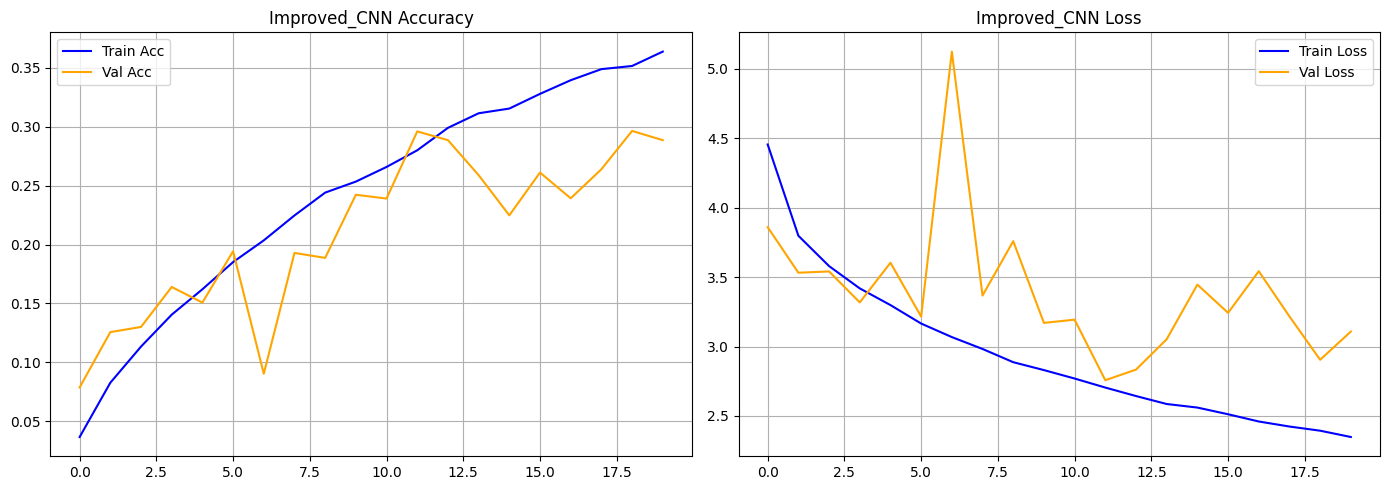

In [51]:
test_loss_imp, test_acc_imp = improved_model.evaluate(test_ds)
print(f"\n Improved CNN - Test Accuracy: {test_acc_imp:.4f} ({test_acc_imp*100:.2f}%)")
print(f"   Test Loss: {test_loss_imp:.4f}")

# Classification report
y_true_imp, y_pred_imp = [], []
for images, labels in test_ds:
    preds = improved_model.predict(images, verbose=0)
    y_pred_imp.extend(np.argmax(preds, axis=1))
    y_true_imp.extend(labels.numpy())

print("\nClassification Report (Improved CNN):")
print(classification_report(y_true_imp, y_pred_imp, target_names=class_names))

plot_history(history, "Improved_CNN")

## Transfer Learning with VGG16 (Frozen Base)

In [52]:
#resize images to 124*124 for VGG16
IMG_SIZE_TL = 124
BATCH_SIZE_TL = 16

# Reload datasets with new size
train_ds_tl = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=(IMG_SIZE_TL, IMG_SIZE_TL), batch_size=BATCH_SIZE_TL, shuffle=True, seed=SEED
)
val_ds_tl = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir, image_size=(IMG_SIZE_TL, IMG_SIZE_TL), batch_size=BATCH_SIZE_TL, shuffle=False, seed=SEED
)
test_ds_tl = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=(IMG_SIZE_TL, IMG_SIZE_TL), batch_size=BATCH_SIZE_TL, shuffle=False, seed=SEED
)

# Normalise to [0,1]
train_ds_tl = train_ds_tl.map(lambda x,y: (x/255.0, y))
val_ds_tl   = val_ds_tl.map(lambda x,y: (x/255.0, y))
test_ds_tl  = test_ds_tl.map(lambda x,y: (x/255.0, y))

Found 17530 files belonging to 100 classes.
Found 4981 files belonging to 100 classes.
Found 2454 files belonging to 100 classes.


## Build VGG16 Transfer Learning Model

In [53]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
base_model.trainable = False   # freeze base

inputs = keras.Input(shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs)
tl_model.compile(optimizer=Adam(learning_rate=1e-4),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
tl_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 124, 124, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,028,644 (57.33 MB)

 Trainable params: 313,956 (1.20 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

##  Train Transfer Learning Model


In [54]:
checkpoint_tl = ModelCheckpoint("tl_vgg16_best.h5", save_best_only=True, monitor='val_accuracy')
earlystop_tl = EarlyStopping(patience=10, restore_best_weights=True)

history_tl = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=[checkpoint_tl, earlystop_tl],
    verbose=1
)

Epoch 1/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0213 - loss: 4.6398

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 73s 60ms/step - accuracy: 0.0414 - loss: 4.4703 - val_accuracy: 0.1686 - val_loss: 4.1176
Epoch 2/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.1146 - loss: 4.0529

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 58s 53ms/step - accuracy: 0.1329 - loss: 3.9541 - val_accuracy: 0.2329 - val_loss: 3.6776
Epoch 3/20
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1717 - loss: 3.6843

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.1798 - loss: 3.6236 - val_accuracy: 0.2664 - val_loss: 3.4025
Epoch 4/20
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2126 - loss: 3.4275

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 56s 51ms/step - accuracy: 0.2205 - loss: 3.3796 - val_accuracy: 0.2953 - val_loss: 3.2049
Epoch 5/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.2444 - loss: 3.2542

...

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 57s 52ms/step - accuracy: 0.4136 - loss: 2.3671 - val_accuracy: 0.4280 - val_loss: 2.3911
Epoch 17/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4218 - loss: 2.3473

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 57s 52ms/step - accuracy: 0.4258 - loss: 2.3247 - val_accuracy: 0.4334 - val_loss: 2.3607
Epoch 18/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4341 - loss: 2.2872

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.4337 - loss: 2.2758 - val_accuracy: 0.4355 - val_loss: 2.3321
Epoch 19/20
1095/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4387 - loss: 2.2656

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.4416 - loss: 2.2491 - val_accuracy: 0.4413 - val_loss: 2.3117
Epoch 20/20
1096/1096 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4462 - loss: 2.2287

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 56s 51ms/step - accuracy: 0.4487 - loss: 2.2140 - val_accuracy: 0.4439 - val_loss: 2.2861


### Evaluate Transfer Learning Model


154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.4552 - loss: 2.2749

 Transfer Learning (VGG16) - Test Accuracy: 0.4552 (45.52%)
   Test Loss: 2.2749

Classification Report (Transfer Learning):
                              precision    recall  f1-score   support

Zingiber officinale -ginger-       0.45      0.38      0.42        26
                     almonds       0.56      0.39      0.46        23
                   aloe vera       0.52      0.44      0.48        25
                 apple fruit       0.59      0.54      0.57        24
                     apricot       0.42      0.42      0.42        24
                   areca nut       0.25      0.12      0.17        24
                 ashwagandha       0.50      0.48      0.49        25
                     avacado       0.67      0.64      0.65        25
                      bamboo       0.47      0.65      0.55        23
                      banana       0.58      0.60      0.59        25
                    beetro

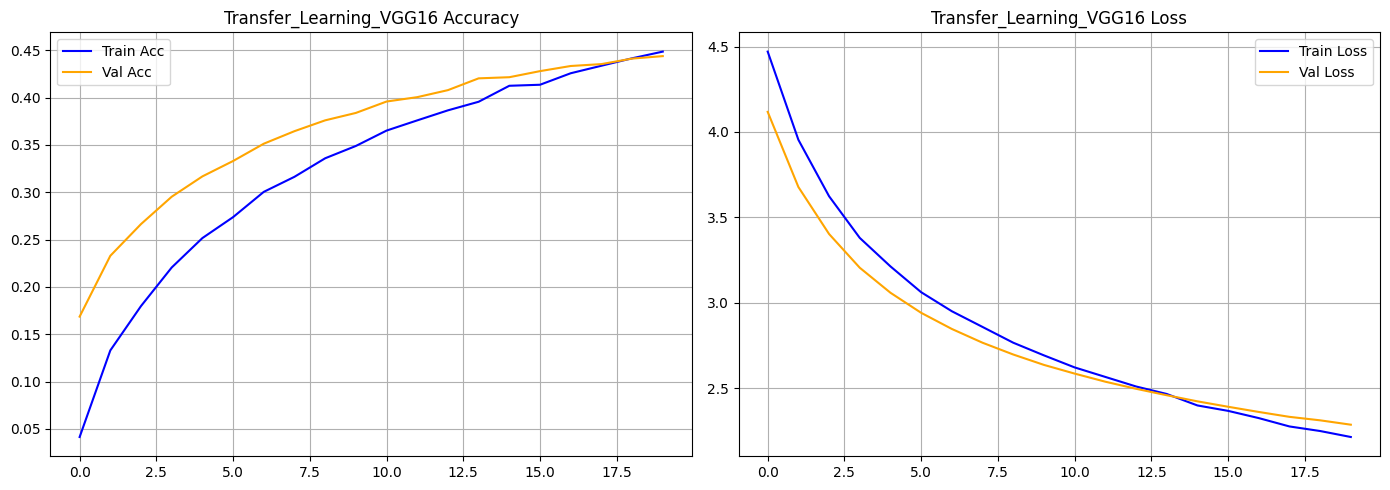

In [55]:
test_loss_tl, test_acc_tl = tl_model.evaluate(test_ds_tl)
print(f"\n Transfer Learning (VGG16) - Test Accuracy: {test_acc_tl:.4f} ({test_acc_tl*100:.2f}%)")
print(f"   Test Loss: {test_loss_tl:.4f}")

y_true_tl, y_pred_tl = [], []
for images, labels in test_ds_tl:
    preds = tl_model.predict(images, verbose=0)
    y_pred_tl.extend(np.argmax(preds, axis=1))
    y_true_tl.extend(labels.numpy())

print("\nClassification Report (Transfer Learning):")
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names))

plot_history(history_tl, "Transfer_Learning_VGG16")

## Save All Trained Models

In [56]:
baseline_model.save("baseline_cnn.h5")
improved_model.save("improved_cnn.h5")
tl_model.save("vgg16_transfer.h5")
print(" All models saved:")
print(" - baseline_cnn.h5")
print(" - improved_cnn.h5")
print(" - vgg16_transfer.h5")

 All models saved:
 - baseline_cnn.h5
 - improved_cnn.h5
 - vgg16_transfer.h5


# Final Accuracy Comparison


In [57]:
print("\n" + "="*50)
print("FINAL TEST ACCURACY COMPARISON")
print("="*50)
print(f"Baseline CNN       : {test_acc*100:.2f}%")
print(f"Improved CNN       : {test_acc_imp*100:.2f}%")
print(f"Transfer Learning  : {test_acc_tl*100:.2f}%")


FINAL TEST ACCURACY COMPARISON
Baseline CNN       : 21.96%
Improved CNN       : 31.13%
Transfer Learning  : 45.52%


### Final Report and Verdict

In [61]:
report = []
verdict = "USABLE"
recommendations = []

report.append("### Dataset Analysis Report")
report.append(f"- Total images processed: {total_images}")
report.append(f"- Total classes: {len(class_names)}")
report.append(f"- Corrupted images found (and skipped): {len(corrupted_files)}")
if corrupted_files:
    report.append("  (Details: " + ", ".join(corrupted_files[:5]) + ("..." if len(corrupted_files) > 5 else "") + ")")
    verdict = "NEEDS IMPROVEMENT"
    recommendations.append("Investigate and replace/remove corrupted image files.")

report.append(f"- Classes with less than 10 images: {len(critically_low_classes)}")
if critically_low_classes:
    report.append("  (Details: " + ", ".join(critically_low_classes[:5]) + ("..." if len(critically_low_classes) > 5 else "") + ")")
    verdict = "NEEDS IMPROVEMENT"
    recommendations.append("Address critically low image counts in some classes (e.g., via data augmentation or collecting more data).")

report.append(f"- Imbalance Ratio (Max/Min class count): {imbalance_ratio:.2f}")
if imbalance_ratio > 3.0:
    report.append("  **Flagged as Imbalanced.**")
    verdict = "NEEDS IMPROVEMENT"
    recommendations.append("Consider rebalancing the dataset (e.g., oversampling minority classes, undersampling majority classes).")

report.append(f"- Classes with potential low visual diversity (brightness/contrast): {len(low_diversity_classes)}")
if low_diversity_classes:
    report.append("  (Details: " + ", ".join(low_diversity_classes[:5]) + ("..." if len(low_diversity_classes) > 5 else "") + ")")
    verdict = "NEEDS IMPROVEMENT"
    recommendations.append("Review classes flagged for low visual diversity; consider additional data augmentation or sourcing more varied images.")

report.append(f"\n### Final Verdict: {verdict}")

if total_images < 300:
    recommendations.append("Dataset is very small; strongly recommend using Transfer Learning (e.g., MobileNetV2) and extensive Data Augmentation.")

if recommendations:
    report.append("\n### Recommendations:")
    for i, rec in enumerate(recommendations):
        report.append(f"{i+1}. {rec}")

print("\n".join(report))

### Dataset Analysis Report
- Total images processed: 25001
- Total classes: 100
- Corrupted images found (and skipped): 0
- Classes with less than 10 images: 0
- Imbalance Ratio (Max/Min class count): 1.03
- Classes with potential low visual diversity (brightness/contrast): 0

### Final Verdict: USABLE
